# Artificial Intelligence - Assignment 2

Github Project Directory: https://github.com/tareqcuet/AI-Assignment-2.git

**Student Name:** Md. Mustafijur Rahman

This notebook contains the implementation and analysis for Assignment 2.



In [ ]:
# Import required libraries

import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

# Problem 1: BFS vs DFS Implementation and Analysis

## Problem 1(a): BFS on Graph

In [16]:
from collections import deque

def bfs(graph, start, goal):
    queue = deque([[start]])
    explored = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in explored:
            explored.add(node)

            for neighbor in graph[node]:
                if neighbor not in explored:
                    new_path = path + [neighbor]
                    queue.append(new_path)

    return None


# Graph from the assignment
graph = {
    'A': ['B'],
    'B': ['C', 'D'],
    'C': ['E'],
    'D': ['F'],
    'E': [],
    'F': []
}

path = bfs(graph, 'A', 'E')

print("BFS path:", path)

BFS path: ['A', 'B', 'C', 'E']


## Problem 1(b): DFS on Graph

In [17]:
def dfs(graph, start, goal):
    stack = [[start]]
    explored = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node == goal:
            return path

        if node not in explored:
            explored.add(node)

            for neighbor in reversed(graph[node]):
                if neighbor not in explored:
                    new_path = path + [neighbor]
                    stack.append(new_path)

    return None


graph = {
    'A': ['B'],
    'B': ['C', 'D'],
    'C': ['E'],
    'D': ['F'],
    'E': [],
    'F': []
}

path = dfs(graph, 'A', 'E')
print("DFS path:", path)

DFS path: ['A', 'B', 'C', 'E']


In [ ]:
Comparison of BFS and DFS 

Traversal order: BFS explores level by level: A → B → C → D → E. DFS goes deep first: A → B → C → E.

Memory usage: BFS generally uses more memory because it stores multiple nodes in the queue. DFS uses less memory by following one branch at a time.

Path length: Both BFS and DFS find the path A → B → C → E, which has 3 moves.

Conclusion: In this tree, both methods find the same path, but BFS explores more nodes before reaching E, while DFS reaches E by going deeper along the branch.

## Problem 1(c): BFS on Grid

In [12]:
from collections import deque

# Grid representation:
# 1 = black cell = open path
# 0 = gray cell = blocked path
grid = [
    [1, 0, 0, 0, 0, 0],  # Row 0
    [1, 1, 1, 1, 1, 1],  # Row 1
    [1, 0, 0, 1, 0, 0],  # Row 2
    [1, 0, 0, 1, 0, 0],  # Row 3, B = (3, 3)
    [1, 0, 1, 1, 0, 0],  # Row 4
    [1, 0, 1, 0, 0, 0],  # Row 5
    [1, 1, 1, 0, 0, 0]   # Row 6, A = (6, 0)
]

# Starting position A and goal position B
start = (6, 0)
goal = (3, 3)

# Four possible movements:
# up, down, left, right
directions = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]


def bfs_grid(grid, start, goal):

    # Queue is used by BFS to explore cells level by level.
    queue = deque([start])

    # Keep track of cells that have already been visited.
    visited = {start}

    # Store the previous cell of each visited cell.
    # This is used later to reconstruct the final path.
    parent = {start: None}

    rows = len(grid)
    cols = len(grid[0])

    # Continue until the queue becomes empty.
    while queue:

        # Remove the first cell from the queue.
        current = queue.popleft()

        # Stop when we reach B.
        if current == goal:
            break

        # Check all four possible directions.
        for dr, dc in directions:

            # Calculate the new row and column.
            nr = current[0] + dr
            nc = current[1] + dc

            # Check whether the new cell is inside the grid.
            if 0 <= nr < rows and 0 <= nc < cols:

                # Check whether the cell is open
                # and has not been visited before.
                if grid[nr][nc] == 1 and (nr, nc) not in visited:

                    # Mark the cell as visited.
                    visited.add((nr, nc))

                    # Store the previous cell.
                    parent[(nr, nc)] = current

                    # Add the cell to the BFS queue.
                    queue.append((nr, nc))

    # If B was not reached, no path exists.
    if goal not in parent:
        return None

    # Reconstruct the path from B back to A.
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = parent[current]

    # Reverse the path so that it goes from A to B.
    path.reverse()

    return path


# Find the BFS path from A to B.
path = bfs_grid(grid, start, goal)

# Display the result.
if path:
    print("BFS path from A to B:")
    print(path)

    # Number of moves = number of cells - 1
    print("Path length:", len(path) - 1)
else:
    print("No path found.")

BFS path from A to B:
[(6, 0), (6, 1), (6, 2), (5, 2), (4, 2), (4, 3), (3, 3)]
Path length: 6


A → (6,1) → (6,2) → (5,2) → (4,2) → (4,3) → B
There are 7 cells in the path, so the number of moves/edges is 6.

## Problem 1(d): DFS on Grid

In [13]:
# Grid representation:
# 1 = black cell = open path
# 0 = gray cell = blocked path
grid = [
    [1, 0, 0, 0, 0, 0],  # Row 0
    [1, 1, 1, 1, 1, 1],  # Row 1
    [1, 0, 0, 1, 0, 0],  # Row 2
    [1, 0, 0, 1, 0, 0],  # Row 3, B = (3, 3)
    [1, 0, 1, 1, 0, 0],  # Row 4
    [1, 0, 1, 0, 0, 0],  # Row 5
    [1, 1, 1, 0, 0, 0]   # Row 6, A = (6, 0)
]

# Starting position A and goal position B
start = (6, 0)
goal = (3, 3)

# Four possible movements:
# Up, Down, Left, Right
directions = [
    (-1, 0),  # Up
    (1, 0),   # Down
    (0, -1),  # Left
    (0, 1)    # Right
]


def dfs_grid(grid, current, goal, visited, path):

    # Add the current cell to the visited set.
    visited.add(current)

    # Add the current cell to the current path.
    path.append(current)

    # If we reach B, the path has been found.
    if current == goal:
        return True

    rows = len(grid)
    cols = len(grid[0])

    # Try each possible direction one by one.
    for dr, dc in directions:

        # Calculate the new row and column.
        nr = current[0] + dr
        nc = current[1] + dc

        # Check that the new cell is inside the grid.
        if 0 <= nr < rows and 0 <= nc < cols:

            # Check that the cell is open
            # and has not been visited before.
            if grid[nr][nc] == 1 and (nr, nc) not in visited:

                # Recursively continue DFS from the new cell.
                if dfs_grid(grid, (nr, nc), goal, visited, path):
                    return True

    # If this cell does not lead to B,
    # remove it from the current path and backtrack.
    path.pop()

    return False


# Set to store visited cells.
visited = set()

# List to store the final DFS path.
path = []

# Start DFS from A.
dfs_grid(grid, start, goal, visited, path)

# Display the result.
if path:
    print("DFS path from A to B:")
    print(path)

    # Number of moves = number of cells - 1
    print("Path length:", len(path) - 1)
else:
    print("No path found.")

DFS path from A to B:
[(6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3)]
Path length: 10


So for DFS, the path found is:
A → (5,0) → (4,0) → (3,0) → (2,0) → (1,0) → (1,1) → (1,2) → (1,3) → (2,3) → B
Path length = 10 moves.

Comparison of BFS and DFS

Traversal order: BFS explores the grid level by level, while DFS explores one path deeply before backtracking.
    
Memory usage: BFS generally uses more memory because it stores many nodes in the queue. DFS uses less memory by following one path at a time.
P
ath length: BFS found the shortest path from A to B with 6 moves, while DFS found a path with 10 moves.
    
Conclusion: BFS is better when we need the shortest path, while DFS can use less memory but does not guarantee the shortest path.


# Problem 2: Depth-Limited Search (DLS)

In [15]:
# Depth-Limited Search (DLS) on the given grid
#
# 1 = black cell = open path
# 0 = gray cell = blocked path
#
# A = start = (6, 0)
# B = goal  = (3, 3)

grid = [
    [1, 0, 0, 0, 0, 0],  # Row 0
    [1, 1, 1, 1, 1, 1],  # Row 1
    [1, 0, 0, 1, 0, 0],  # Row 2
    [1, 0, 0, 1, 0, 0],  # Row 3, B
    [1, 0, 1, 1, 0, 0],  # Row 4
    [1, 0, 1, 0, 0, 0],  # Row 5
    [1, 1, 1, 0, 0, 0]   # Row 6, A
]

start = (6, 0)
goal = (3, 3)

# Possible movements: Up, Down, Left, Right
directions = [
    (-1, 0),  # Up
    (1, 0),   # Down
    (0, -1),  # Left
    (0, 1)    # Right
]


def dls(grid, current, goal, depth, limit, visited, path, expanded):
    """
    Depth-Limited Search using recursive DFS.

    depth  = current depth of the node
    limit  = maximum depth allowed
    visited = cells already visited on the current search path
    path   = current path
    expanded = stores nodes that are expanded
    """

    # Add the current cell to the current path.
    path.append(current)

    # If we reach B, the search is successful.
    if current == goal:
        return True

    # Do not expand nodes beyond the depth limit.
    if depth == limit:
        path.pop()
        return False

    # Count this node as expanded because we will check its neighbors.
    expanded.append(current)

    # Explore neighboring cells.
    for dr, dc in directions:

        # Calculate the new row and column.
        nr = current[0] + dr
        nc = current[1] + dc

        # Check if the new position is inside the grid.
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]):

            # Check if the cell is open and not already
            # visited on the current path.
            if grid[nr][nc] == 1 and (nr, nc) not in visited:

                # Add the new cell to the current search path.
                visited.add((nr, nc))

                # Continue searching recursively.
                if dls(
                    grid,
                    (nr, nc),
                    goal,
                    depth + 1,
                    limit,
                    visited,
                    path,
                    expanded
                ):
                    return True

                # Remove the cell when backtracking.
                visited.remove((nr, nc))

    # Remove the current cell when backtracking.
    path.pop()

    return False


def run_dls(limit):
    """
    Run DLS with a specified depth limit.
    """

    path = []
    expanded = []
    visited = {start}

    found = dls(
        grid,
        start,
        goal,
        0,
        limit,
        visited,
        path,
        expanded
    )

    print(f"\nDepth Limit = {limit}")

    if found:
        print("Goal found!")
        print("Path:", path)
        print("Path length:", len(path) - 1)
    else:
        print("Goal not found within the depth limit.")
        print("Path length: N/A")

    print("Number of expanded nodes:", len(expanded))
    print("Expanded nodes:", expanded)

    return found, path, expanded


# Run DLS with depth limit 6
result_6 = run_dls(6)

# Run DLS with depth limit 10
result_10 = run_dls(10)


Depth Limit = 6
Goal found!
Path: [(6, 0), (6, 1), (6, 2), (5, 2), (4, 2), (4, 3), (3, 3)]
Path length: 6
Number of expanded nodes: 11
Expanded nodes: [(6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (6, 1), (6, 2), (5, 2), (4, 2), (4, 3)]

Depth Limit = 10
Goal found!
Path: [(6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3)]
Path length: 10
Number of expanded nodes: 11
Expanded nodes: [(6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (1, 1), (1, 2), (1, 3), (2, 3)]


Comparison of DLS with Different Depth Limits

DLS with a depth limit of 6 was able to reach the goal because the path from A to B can be reached within 6 moves. It found the shorter path with a length of 6.
When the depth limit was increased to 10, DLS was allowed to explore deeper into the grid. Because DLS follows one path deeply before backtracking, it found a different path with 10 moves. So, increasing the depth limit does not always mean that DLS will find a better or shorter path.

The depth limit also affects completeness. With a limit that is too small, DLS may fail to find the goal even when a path exists. A larger limit gives it more opportunity to reach the goal, but it may also explore more unnecessary paths.

Compared with BFS, BFS found the shortest path of 6 moves because it explores the grid level by level. Compared with DFS, DLS behaves similarly because both search deeply and use relatively little memory. The main difference is that DLS puts a maximum limit on how deep the search can go.

Overall, DLS provides a balance between BFS and DFS: it uses less memory than BFS and allows us to control how deep the search goes, but it does not guarantee the shortest path.


Problem 3: Pathfinding in a Weighted Graph

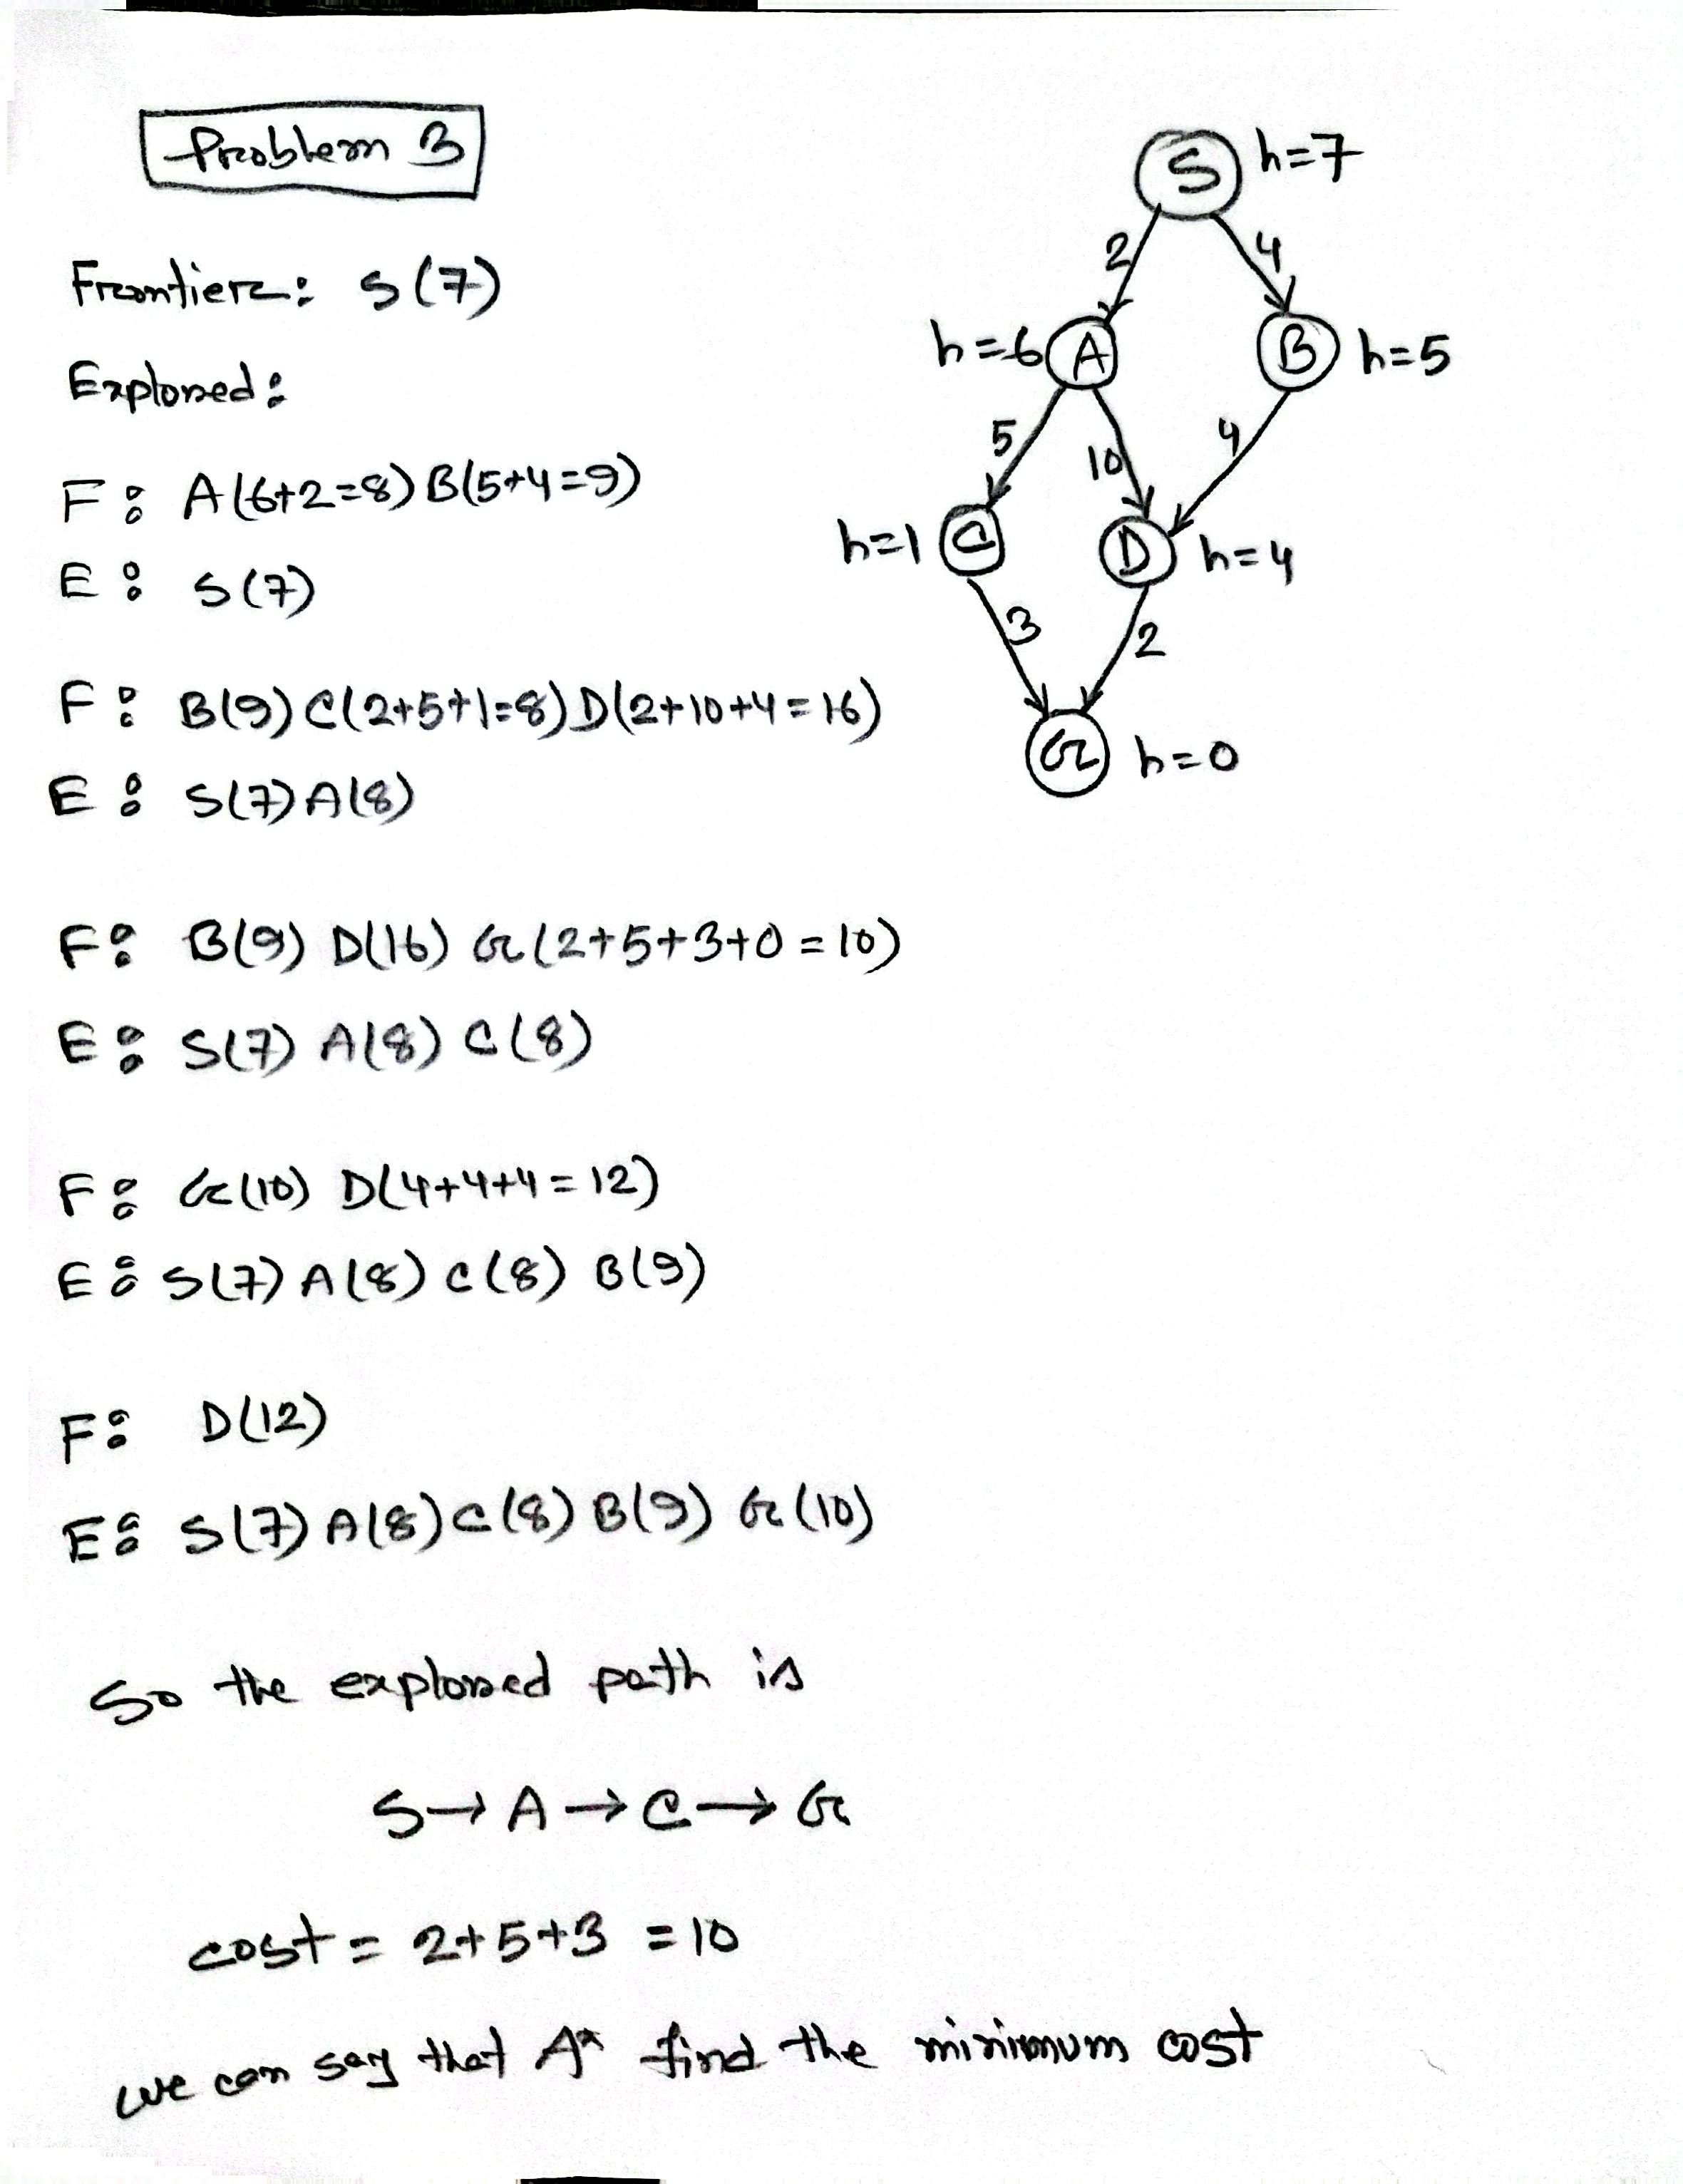

# Problem 4: Tic-Tac-Toe Minimax

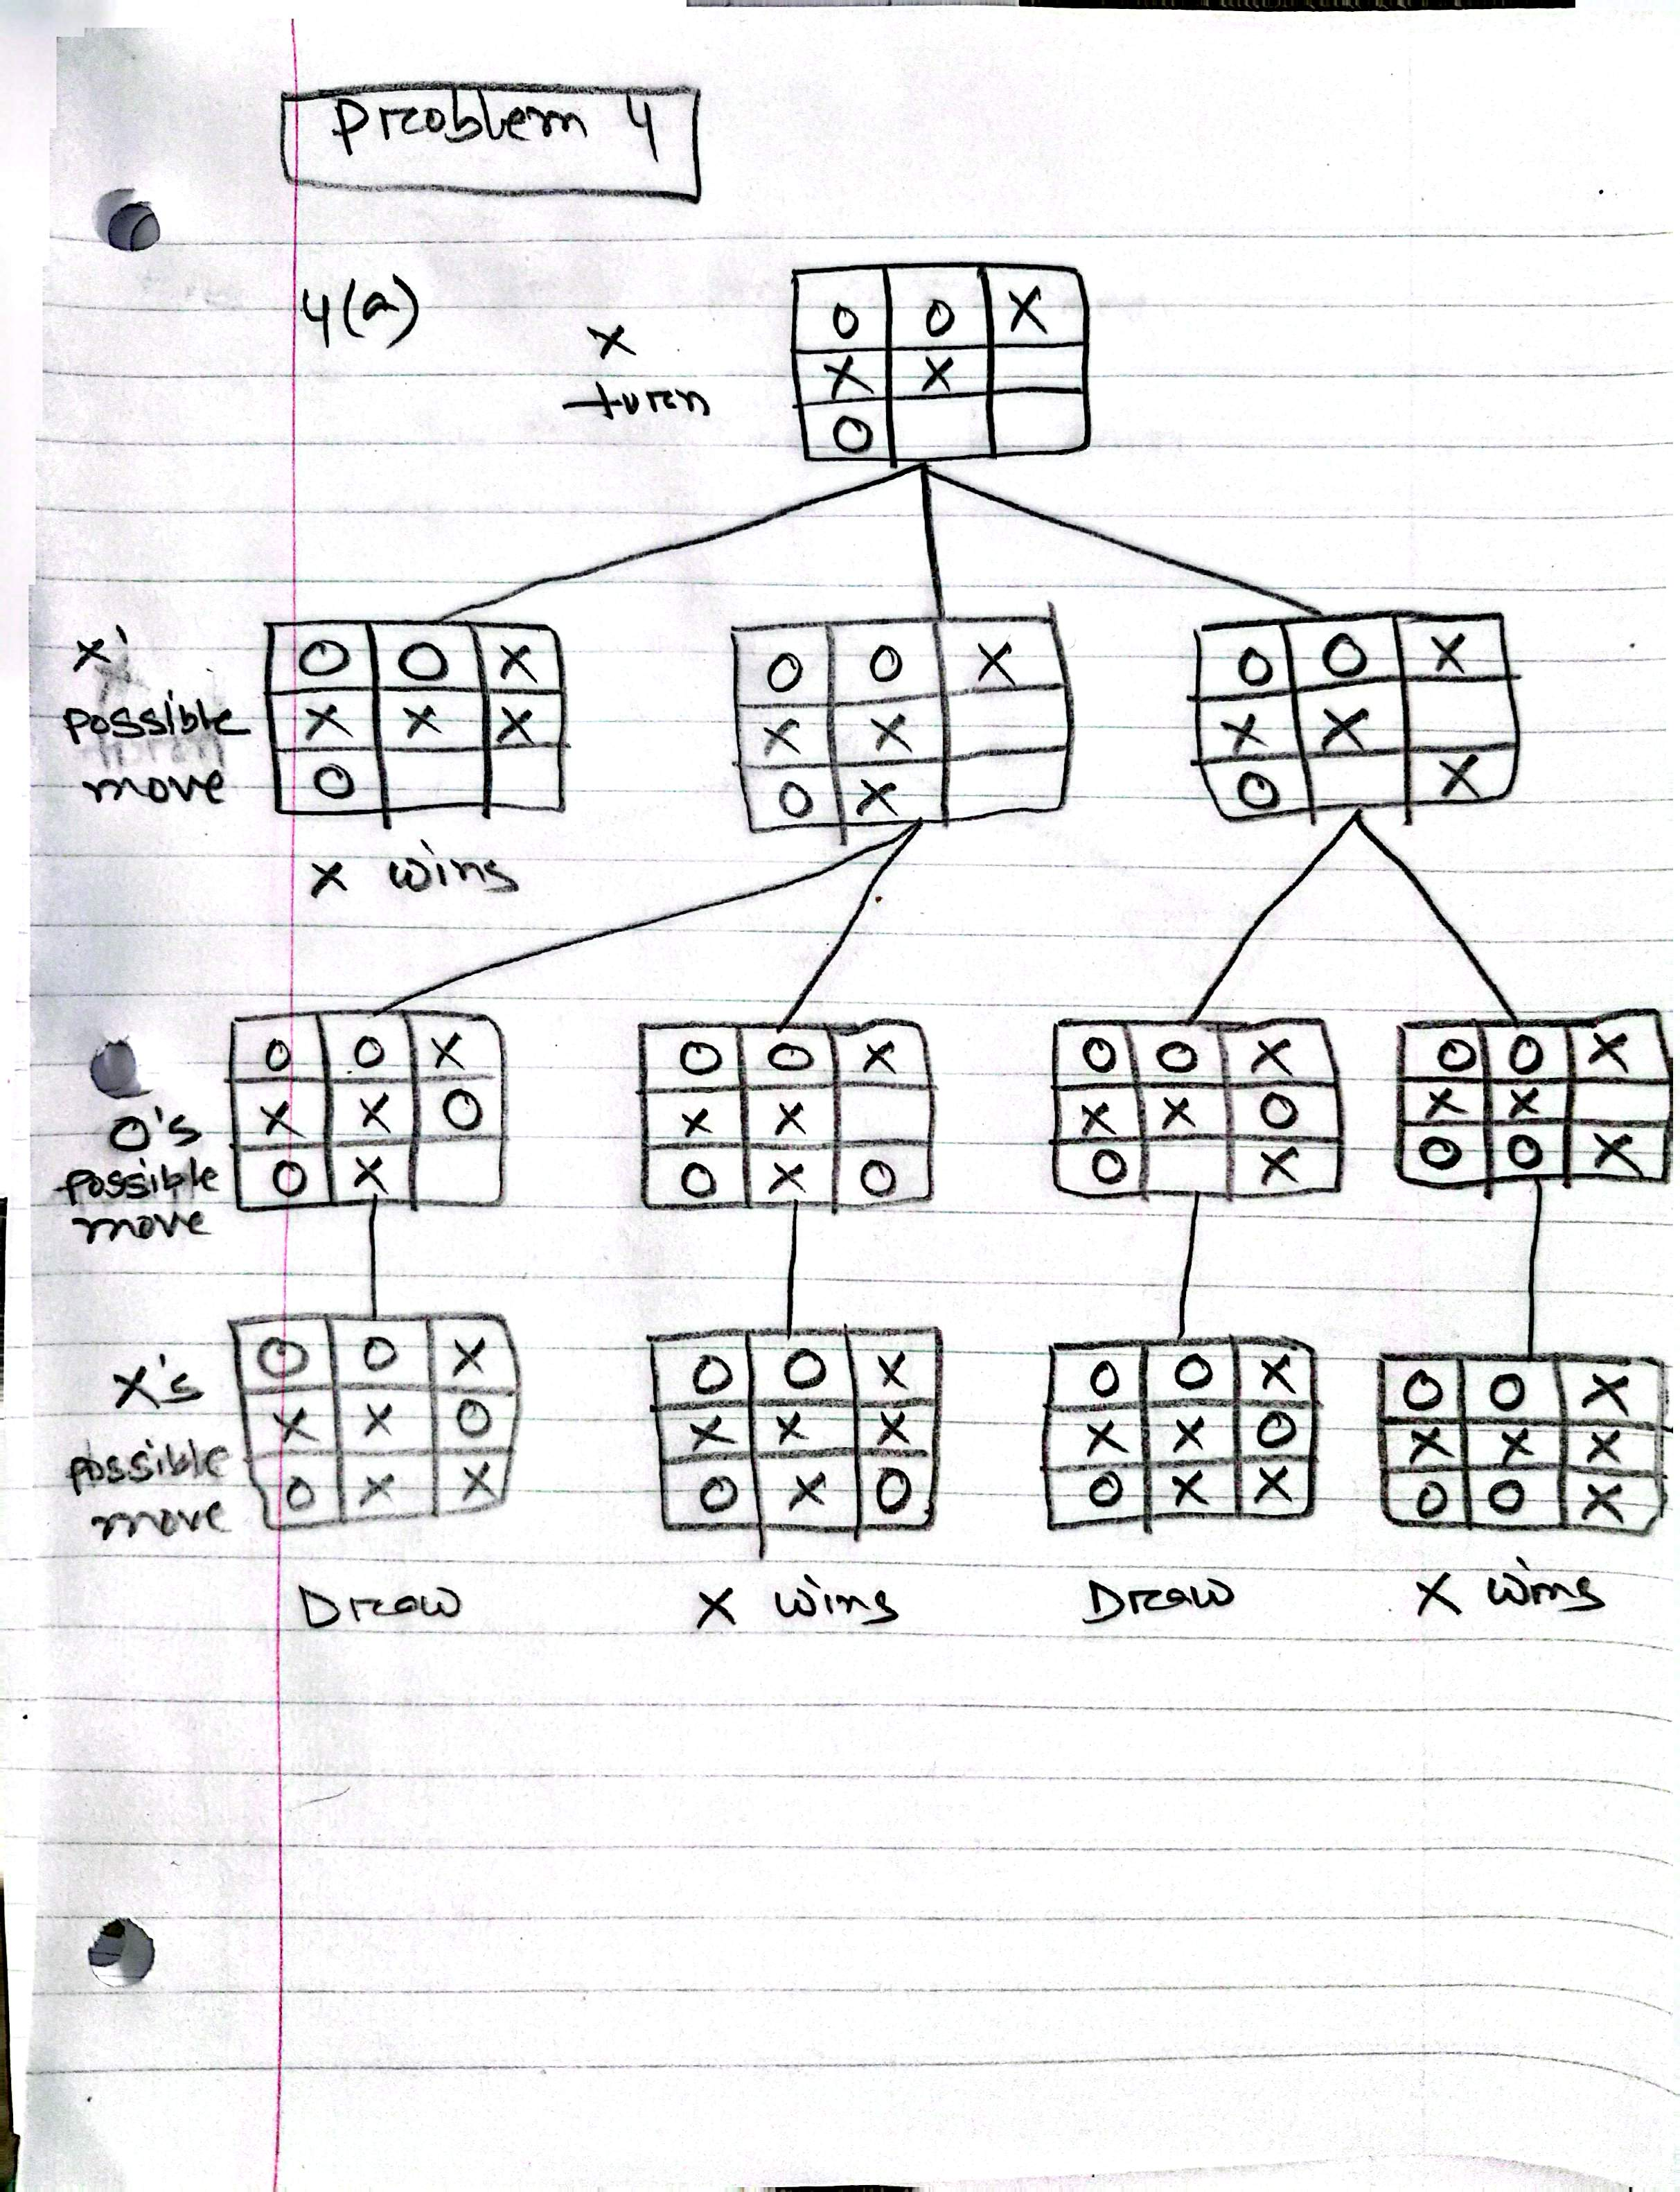

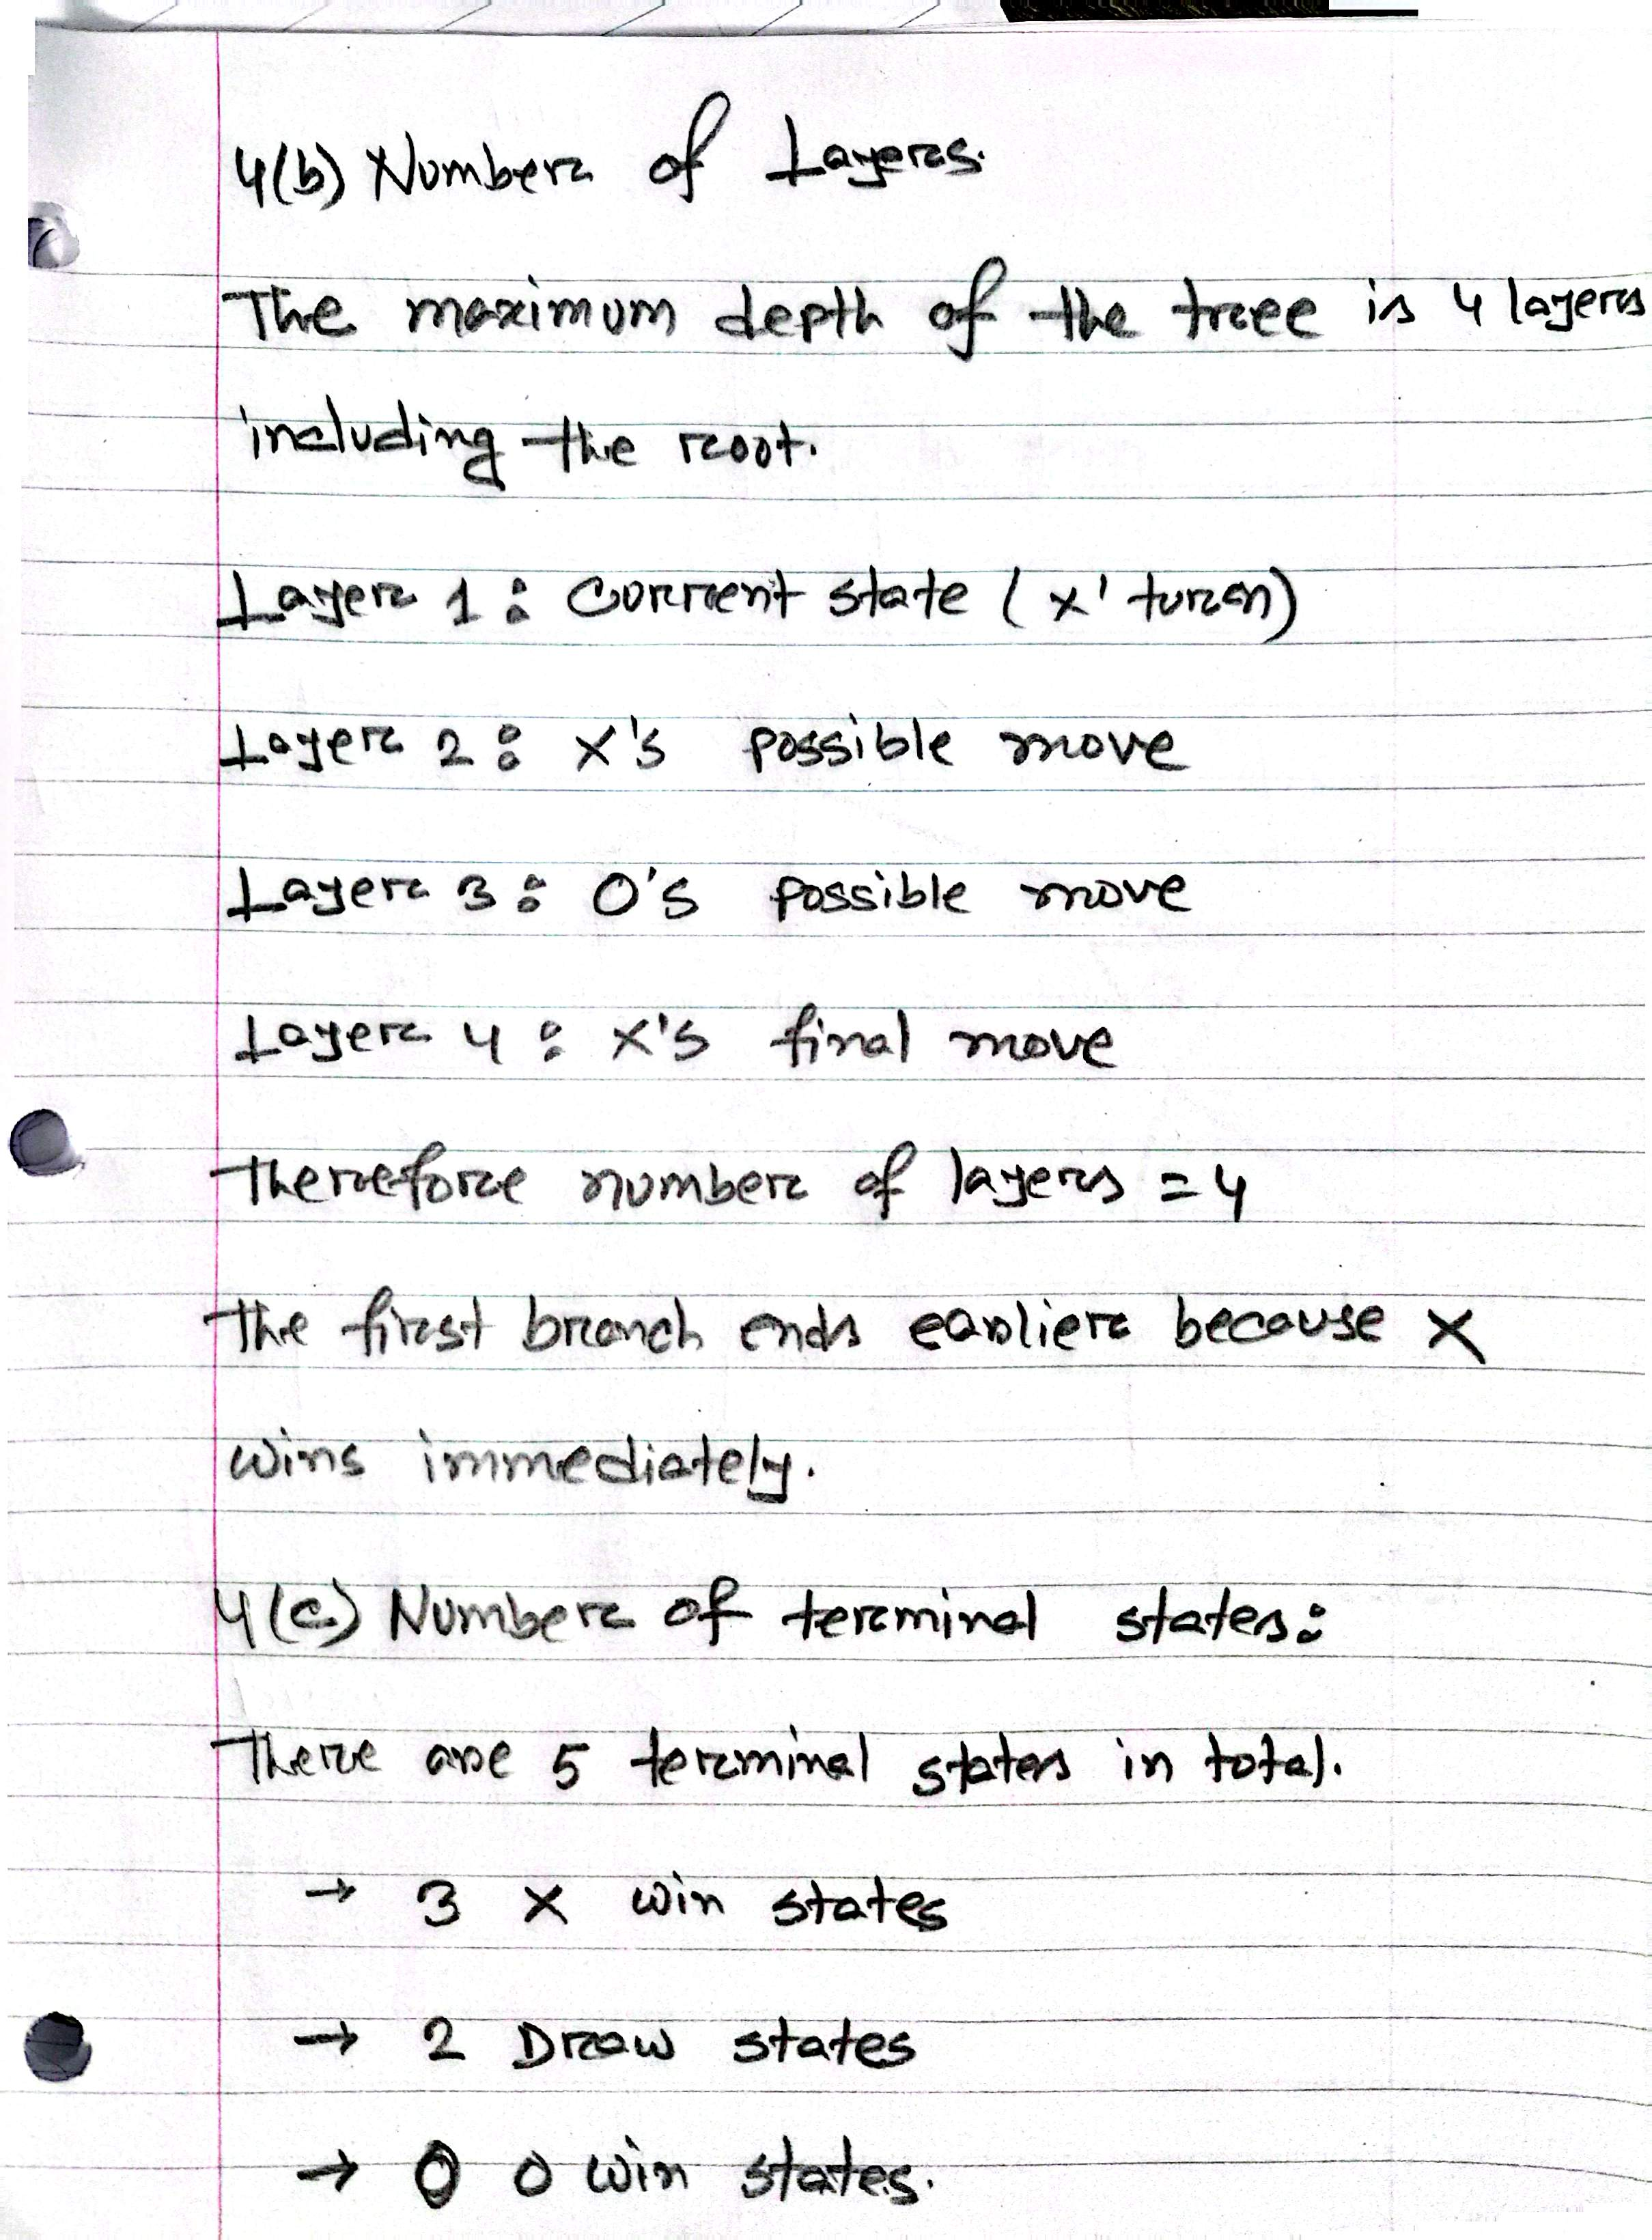

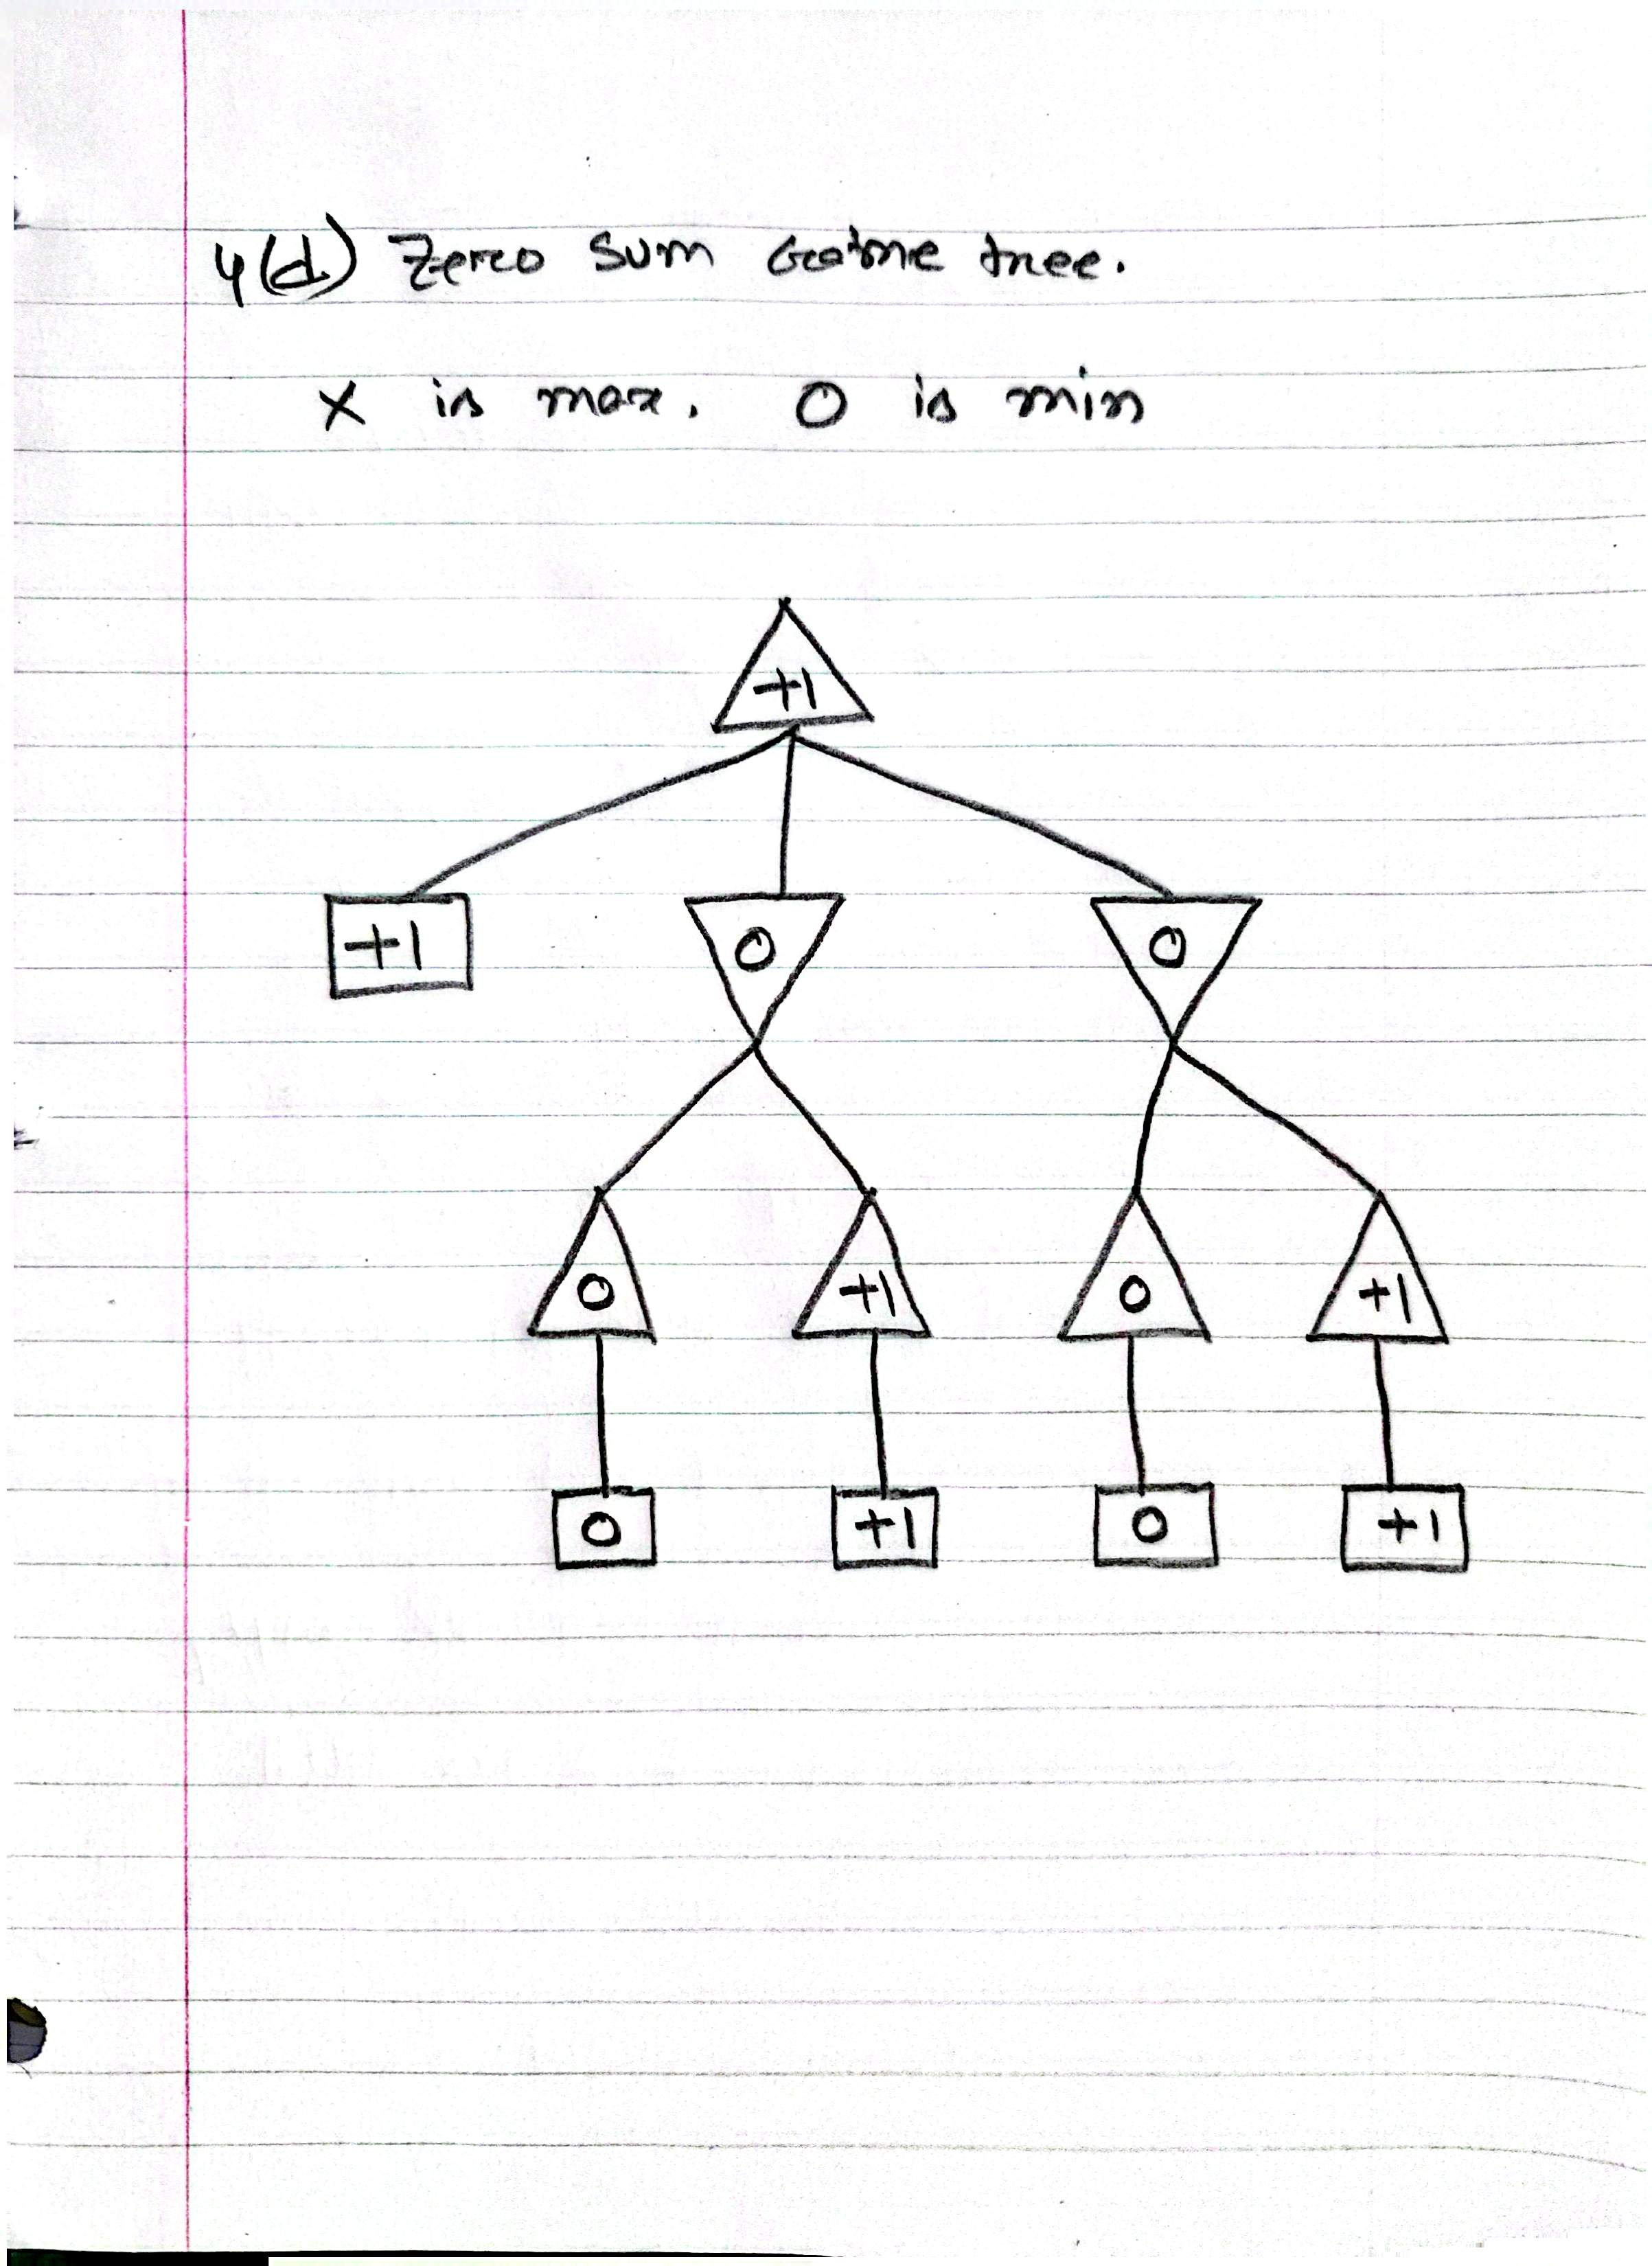

# Problem 5: Zero-Sum Game Tree and Pruning

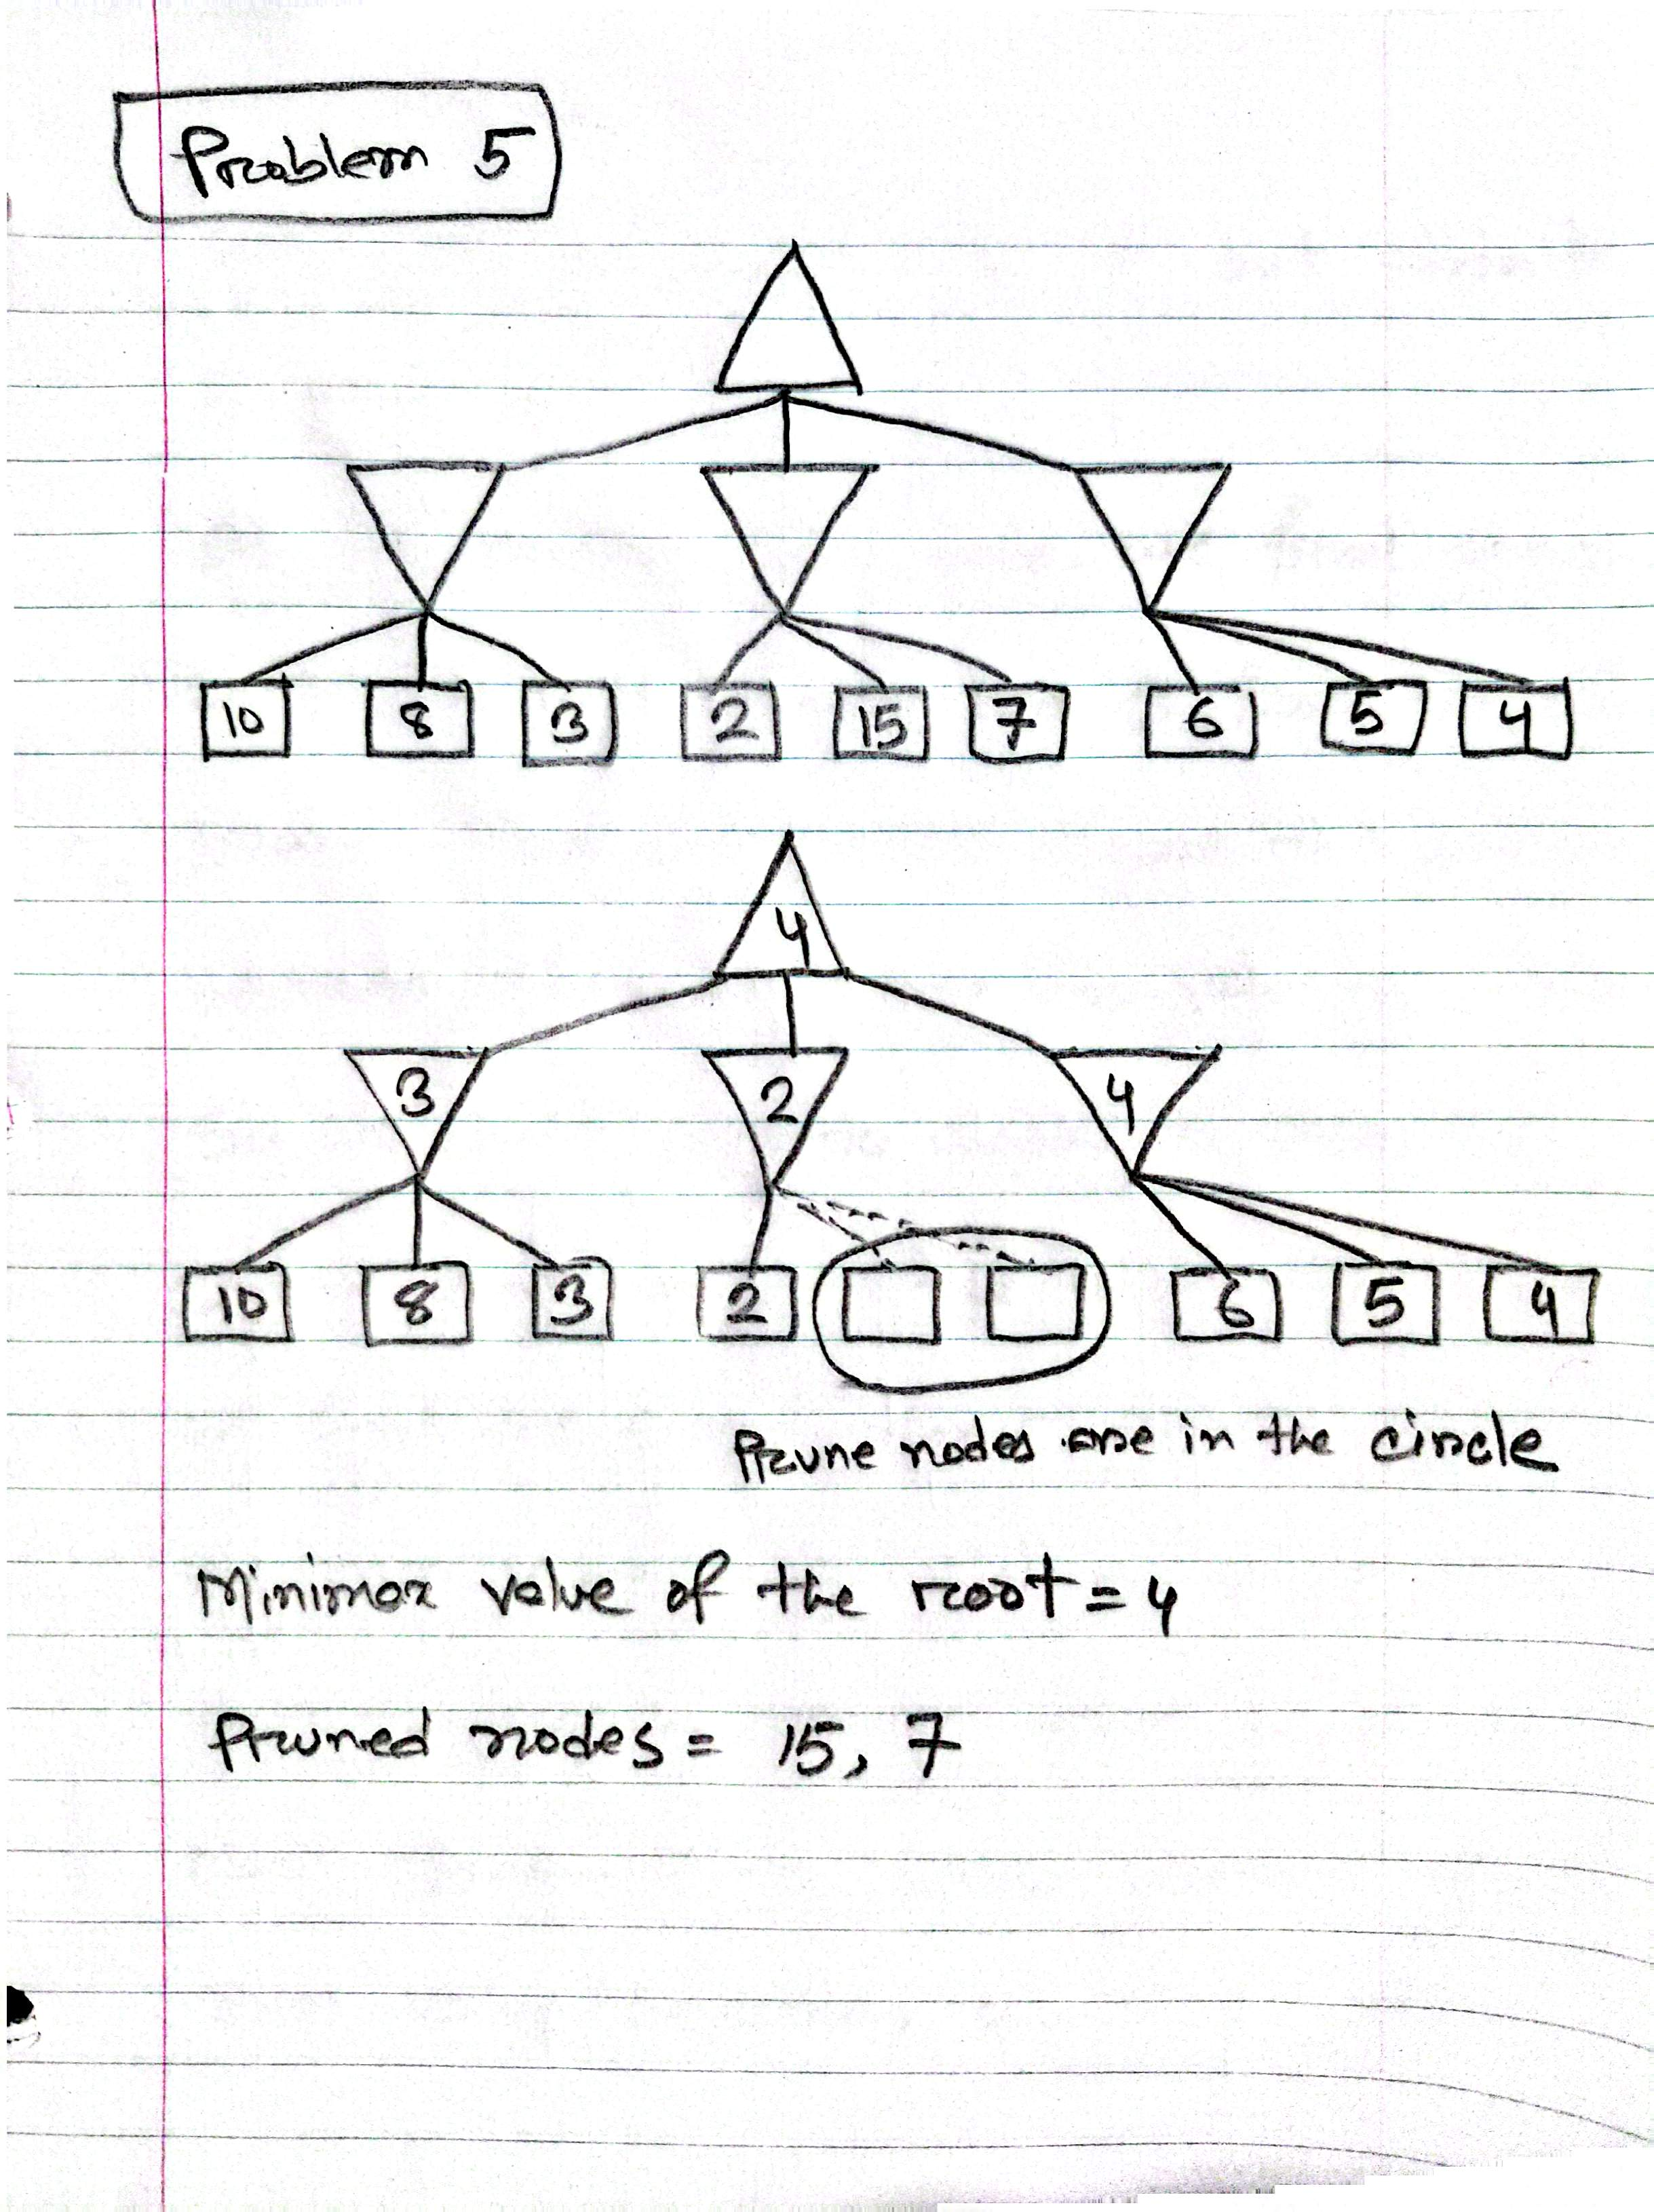

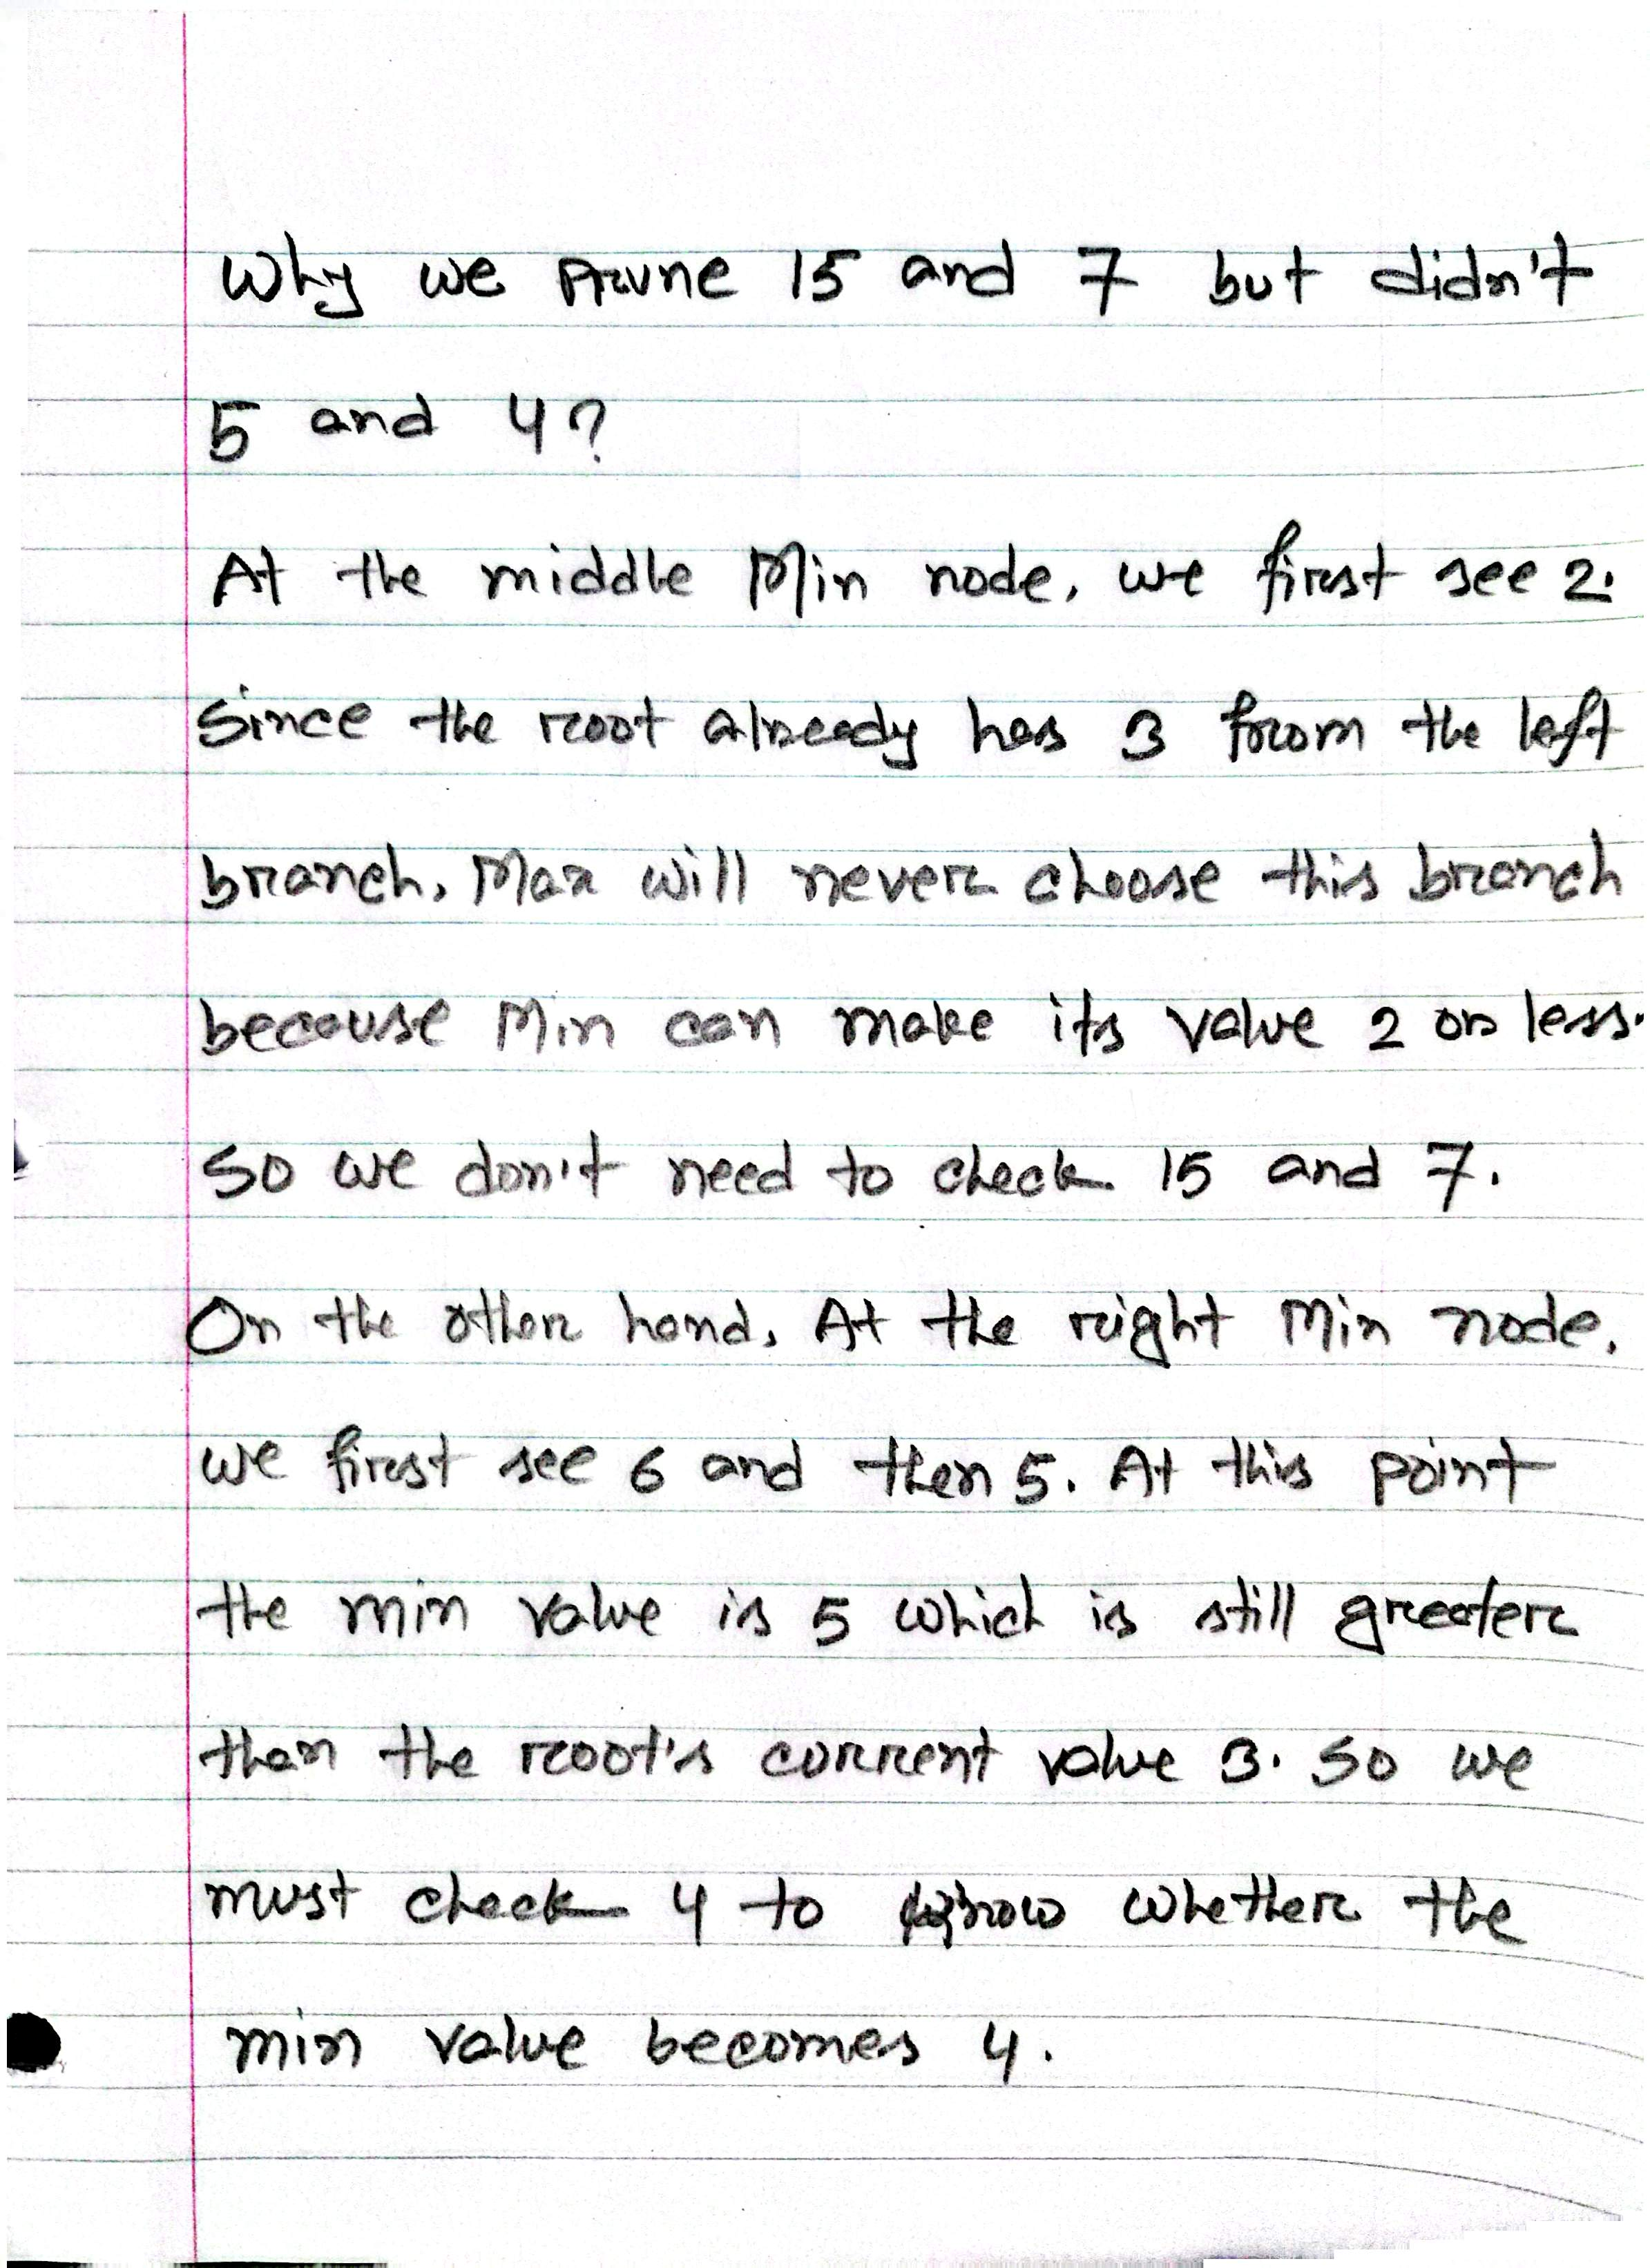